In [5]:
from pyha_analyzer import extractors
from pyha_analyzer import preprocessors

from pydub import AudioSegment

import librosa
import numpy as np
import scipy
import matplotlib.pyplot as plt
import os
import requests
import cv2 as cv

In [3]:
!pip install opencv-python

     |████████████████████████████████| 67.0 MB 3.8 MB/s eta 0:00:01


In [ ]:
# Template to use: /home/super/data/music/templates/Streptopelia_semitorquata_100465.mp3
# Clip to use: /home/super/data/music/Liked Sounds/Location A Sand Forrest/Zoom_F3/030525_003_20250503_174500.wav

def compute_mel_spectrogram(y, sr, n_mels=128, hop_length=512):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=hop_length)
    S_dB = librosa.power_to_db(S, ref=np.max)
    return S_dB

In [7]:
CLIP_PATH = "/home/super/data/music/Liked Sounds/Location A Sand Forrest/Zoom_F3/030525_003_20250503_174500.wav"
TEMPLATE_PATH = "/home/super/data/music/templates/Streptopelia_semitorquata_100465.mp3"

y, sr = librosa.load(TEMPLATE_PATH, sr=None)
template_spectrogram = compute_mel_spectrogram(y, sr)
template_db = librosa.amplitude_to_db(np.abs(template_spectrogram), ref=np.max)

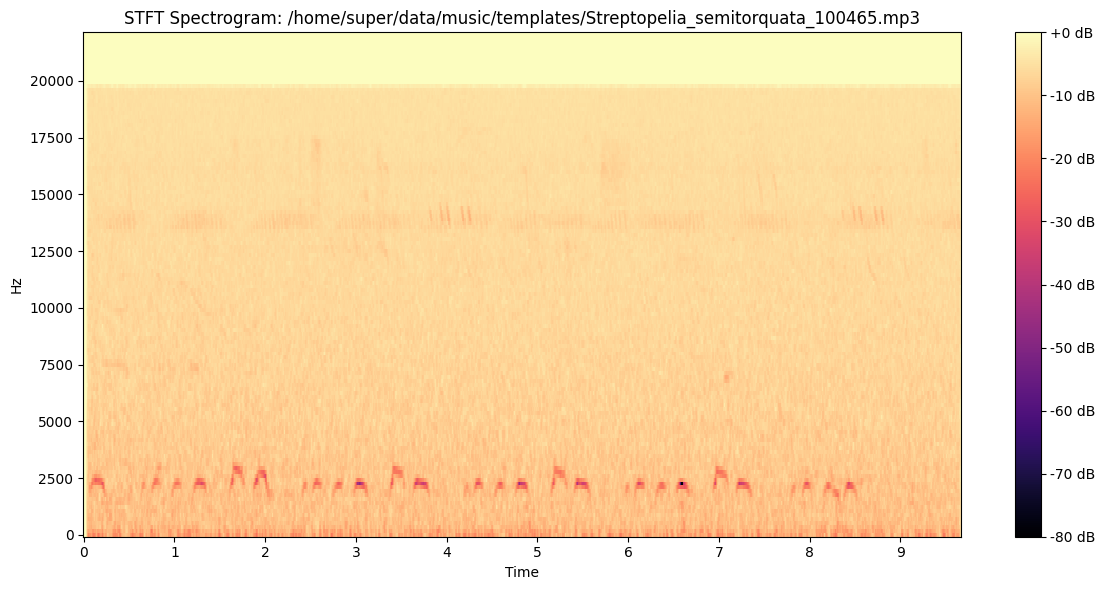

In [8]:
plt.figure(figsize=(12, 6))
librosa.display.specshow(template_db, sr=sr, hop_length=512, x_axis='time', y_axis='linear')
plt.colorbar(format="%+2.0f dB")
plt.title(f"STFT Spectrogram: {TEMPLATE_PATH}")
plt.tight_layout()
plt.show()

In [10]:
def spectrogram_to_image(S_dB):
    img = (S_dB - S_dB.min()) / (S_dB.max() - S_dB.min())
    img = (img * 255).astype(np.uint8)
    return img

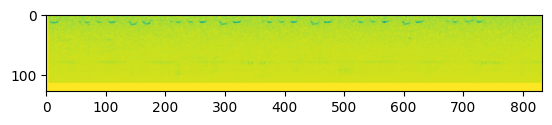

In [ ]:
img = spectrogram_to_image(template_db)

plt.imshow(img)
plt.show()

Match score: 0.6666
Best match location: (8001, 0)


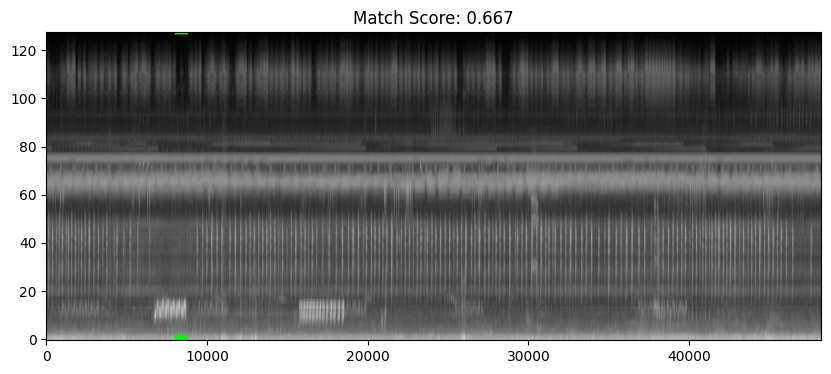

In [15]:
CLIP_PATH = "/home/super/data/music/Liked Sounds/Location A Sand Forrest/Zoom_F3/030525_003_20250503_174500.wav"
TEMPLATE_PATH = "/home/super/data/music/templates/Streptopelia_semitorquata_100465.mp3"

y_clip, sr_clip = librosa.load(CLIP_PATH, sr=None)
y_template, sr_template = librosa.load(TEMPLATE_PATH, sr=None)

clip_spec = compute_mel_spectrogram(y_clip, sr_clip)
template_spec = compute_mel_spectrogram(y_template, sr_template)

clip_img = spectrogram_to_image(clip_spec)
template_img = spectrogram_to_image(template_spec)

res = cv.matchTemplate(clip_img, template_img, cv.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

print(f"Match score: {max_val:.4f}")
print(f"Best match location: {max_loc}")

top_left = max_loc
h, w = template_img.shape
bottom_right = (top_left[0] + w, top_left[1] + h)

vis = cv.cvtColor(clip_img, cv.COLOR_GRAY2BGR)
cv.rectangle(vis, top_left, bottom_right, (0, 255, 0), 2)

plt.figure(figsize=(10, 4))
plt.imshow(vis, aspect='auto', origin='lower', cmap='gray')
plt.title(f"Match Score: {max_val:.3f}")
plt.show()

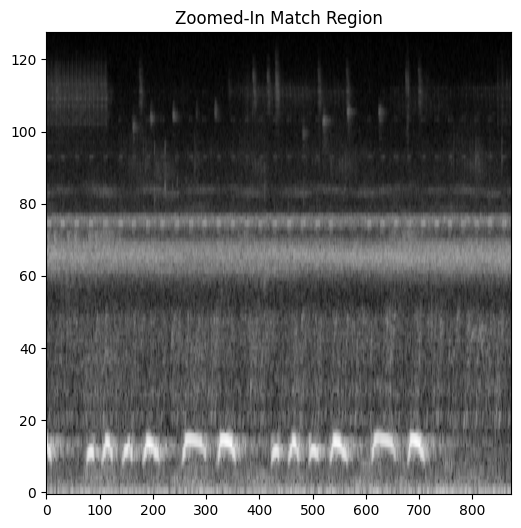

In [16]:
margin = 20
x1 = max(0, top_left[0] - margin)
x2 = min(clip_img.shape[1], bottom_right[0] + margin)
y1 = max(0, top_left[1] - margin)
y2 = min(clip_img.shape[0], bottom_right[1] + margin)

zoom_region = clip_img[y1:y2, x1:x2]

plt.figure(figsize=(6, 6))
plt.imshow(zoom_region, aspect='auto', origin='lower', cmap='gray')
plt.title("Zoomed-In Match Region")
plt.show()

Found 17164 matches above threshold 0.6

Kept 366 non-overlapping matches above threshold 0.6

Match at 244.97 sec (Score: 0.600)
Match at 244.97 sec (Score: 0.600)
Match at 244.97 sec (Score: 0.601)
Match at 244.97 sec (Score: 0.601)
Match at 244.97 sec (Score: 0.601)
Match at 244.97 sec (Score: 0.600)
Match at 244.97 sec (Score: 0.601)
Match at 244.97 sec (Score: 0.601)
Match at 244.97 sec (Score: 0.601)
Match at 244.97 sec (Score: 0.601)
Match at 244.97 sec (Score: 0.601)
Match at 244.97 sec (Score: 0.601)
Match at 244.97 sec (Score: 0.601)
Match at 244.97 sec (Score: 0.601)
Match at 244.97 sec (Score: 0.601)
Match at 244.97 sec (Score: 0.601)
Match at 244.97 sec (Score: 0.601)
Match at 244.97 sec (Score: 0.601)
Match at 244.97 sec (Score: 0.601)
Match at 244.97 sec (Score: 0.601)
Match at 244.97 sec (Score: 0.601)
Match at 244.97 sec (Score: 0.602)
Match at 244.97 sec (Score: 0.603)
Match at 244.97 sec (Score: 0.603)
Match at 244.97 sec (Score: 0.603)
Match at 244.97 sec (Score: 0.

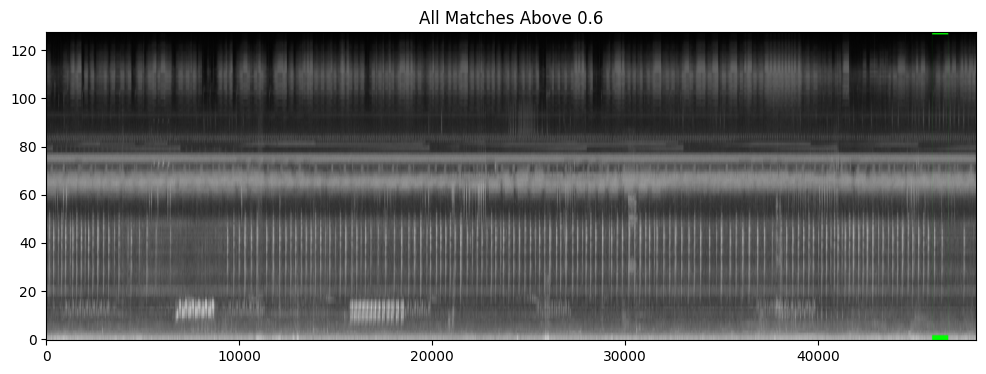

In [ ]:
THRESHOLD = 0.6
SUPPRESSION_DISTANCE = 50

locations = np.where(res >= THRESHOLD)
matches = []
for pt in zip(*locations[::-1]):
    x, y = pt
    score = res[y, x]
    matches.append((y, x, score))

matches.sort(key=lambda x: x[1], reverse=True)

print(f"Found {len(matches)} matches above threshold {THRESHOLD}\n")

selected = []
taken_cols = []

for y, x, score in matches:
    if all(abs(x - xc) > SUPPRESSION_DISTANCE for _, xc, _ in selected):
        selected.append((y, x, score))

print(f"Kept {len(selected)} non-overlapping matches above threshold {THRESHOLD}\n")

seconds_per_col = 512 / sr_clip
template_cols = template_img.shape[1]

plt.figure(figsize=(12, 4))
vis = cv.cvtColor(clip_img, cv.COLOR_GRAY2BGR)
for y, x, score in matches:
    top_left = pt
    bottom_right = (pt[0] + template_img.shape[1], pt[1] + template_img.shape[0])
    cv.rectangle(vis, top_left, bottom_right, (0, 255, 0), 2)

    timestamp = pt[0] * seconds_per_col
    print(f"Match at {timestamp:.2f} sec (Score: {score:.3f})")

plt.imshow(vis, aspect='auto', origin='lower', cmap='gray')
plt.title(f"All Matches Above {THRESHOLD}")
plt.show()